# Combined Temperature and Load Analytics
## Correlation Analysis Between City Temperatures and Energy Loads

This notebook analyzes the relationship between temperature patterns and electricity load demand across multiple US cities:
- **Load Cities**: Boston, New York, Chicago, Minneapolis
- **Temperature Cities**: Boston, New York, Chicago, Minneapolis, Houston, Dallas

**Data Source**: Pre-processed pickle files from Temperature_Analytics2.ipynb and Load_Analytics.ipynb

## 1. Setup and Data Loading

In [1]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import pickle
import warnings
warnings.filterwarnings('ignore')

from wxderivs import SET_TARGET_US_CITIES, MONTH_CDD, MONTH_HDD, DIR_WORK

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("✓ Libraries imported successfully")

0 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Essen.csv
1 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Boston.csv
2 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Philadelphia.csv
3 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/NewYork.csv
4 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Burbank.csv
5 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/London.csv
6 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Dallas.csv
7 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Paris.csv
8 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Portland.csv
9 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/tempe

In [2]:
# Load temperature data
with open('../data/processed/temperature_analysis_data.pkl', 'rb') as f:
    temp_data = pickle.load(f)

# Load load data
with open('../data/processed/all_analysis_data.pkl', 'rb') as f:
    load_data = pickle.load(f)

print("Temperature Data Keys:", list(temp_data.keys()))
print("\nLoad Data Keys:", list(load_data.keys()))

Temperature Data Keys: ['df_boston', 'df_ny', 'df_chicago', 'df_minneapolis', 'df_houston', 'df_dallas', 'df_res', 'df_cdd_temp_res', 'df_hdd_temp_res', 'df_result', 'region_fit', 'df_tdc_temp_cdd_res', 'df_tdc_temp_hdd_res', 'dct_evi_temp_res_right', 'dct_evi_temp_res_left', 'df_evi_res_right', 'df_evi_res_left', 'boston_garch_fit', 'summary_stats', 'volatility_by_doy']

Load Data Keys: ['df_boston', 'df_ny', 'df_chicago', 'df_minneapolis', 'df_res', 'df_cdd_load_res', 'df_hdd_load_res', 'df_result', 'df_tdc_load_cdd_res', 'df_tdc_load_hdd_res', 'dct_evi_load_res_right', 'dct_evi_load_res_left', 'df_evi_res_right', 'df_evi_res_left']


In [3]:
# Extract temperature dataframes
temp_boston = temp_data['df_boston'].copy()
temp_ny = temp_data['df_ny'].copy()
temp_chicago = temp_data['df_chicago'].copy()
temp_minneapolis = temp_data['df_minneapolis'].copy()
temp_houston = temp_data['df_houston'].copy()
temp_dallas = temp_data['df_dallas'].copy()

# Extract load dataframes
load_boston = load_data['df_boston'].copy()
load_ny = load_data['df_ny'].copy()
load_chicago = load_data['df_chicago'].copy()
load_minneapolis = load_data['df_minneapolis'].copy()

print("Temperature DataFrames:")
print(f"  Boston: {temp_boston.shape}")
print(f"  New York: {temp_ny.shape}")
print(f"  Chicago: {temp_chicago.shape}")
print(f"  Minneapolis: {temp_minneapolis.shape}")
print(f"  Houston: {temp_houston.shape}")
print(f"  Dallas: {temp_dallas.shape}")

print("\nLoad DataFrames:")
print(f"  Boston: {load_boston.shape}")
print(f"  New York: {load_ny.shape}")
print(f"  Chicago: {load_chicago.shape}")
print(f"  Minneapolis: {load_minneapolis.shape}")

Temperature DataFrames:
  Boston: (3287, 3)
  New York: (3287, 3)
  Chicago: (3287, 3)
  Minneapolis: (3287, 3)
  Houston: (3287, 3)
  Dallas: (3287, 3)

Load DataFrames:
  Boston: (3287, 6)
  New York: (3287, 3)
  Chicago: (3286, 3)
  Minneapolis: (3287, 3)


## 2. Data Preparation and Alignment

In [4]:
# Prepare combined datasets for correlation analysis
# Ensure dates are properly indexed and aligned

def prepare_dataframe(df, temp_col='avg_temp', load_col='avg_load'):
    """Standardize dataframe format"""
    df_clean = df.copy()
    
    # Ensure index is datetime
    if not isinstance(df_clean.index, pd.DatetimeIndex):
        if 'date' in df_clean.columns:
            df_clean['date'] = pd.to_datetime(df_clean['date'])
            df_clean.set_index('date', inplace=True)
    
    # Sort by date
    df_clean.sort_index(inplace=True)
    
    return df_clean

# Prepare temperature dataframes
temp_boston = prepare_dataframe(temp_boston)
temp_ny = prepare_dataframe(temp_ny)
temp_chicago = prepare_dataframe(temp_chicago)
temp_minneapolis = prepare_dataframe(temp_minneapolis)

# Prepare load dataframes
load_boston = prepare_dataframe(load_boston)
load_ny = prepare_dataframe(load_ny)
load_chicago = prepare_dataframe(load_chicago)
load_minneapolis = prepare_dataframe(load_minneapolis)

print("✓ DataFrames prepared and indexed by date")

✓ DataFrames prepared and indexed by date


In [5]:
# Create combined datasets for each city
def merge_temp_load(temp_df, load_df, city_name):
    """Merge temperature and load data on date index"""
    # Select relevant columns - temperature columns are tmin, tmax, tavg
    # Load columns are min_load, max_load, avg_load
    temp_cols = ['tmin', 'tmax', 'tavg'] if 'tavg' in temp_df.columns else [col for col in temp_df.columns if col.startswith('t')]
    load_cols = ['min_load', 'max_load', 'avg_load'] if 'avg_load' in load_df.columns else [col for col in load_df.columns if 'load' in col.lower()]
    
    # Filter to only existing columns
    temp_cols = [col for col in temp_cols if col in temp_df.columns]
    load_cols = [col for col in load_cols if col in load_df.columns]
    
    # Merge on date index
    combined = pd.merge(
        temp_df[temp_cols],
        load_df[load_cols],
        left_index=True,
        right_index=True,
        how='inner'
    )
    
    # Rename columns to be more descriptive
    rename_dict = {
        'tmin': f'{city_name}_tmin',
        'tmax': f'{city_name}_tmax',
        'tavg': f'{city_name}_tavg',
        'min_load': f'{city_name}_min_load',
        'max_load': f'{city_name}_max_load',
        'avg_load': f'{city_name}_avg_load'
    }
    
    # Only rename columns that exist
    rename_dict = {k: v for k, v in rename_dict.items() if k in combined.columns}
    combined.rename(columns=rename_dict, inplace=True)
    
    return combined

# Create combined datasets
boston_combined = merge_temp_load(temp_boston, load_boston, 'Boston')
ny_combined = merge_temp_load(temp_ny, load_ny, 'NewYork')
chicago_combined = merge_temp_load(temp_chicago, load_chicago, 'Chicago')
minneapolis_combined = merge_temp_load(temp_minneapolis, load_minneapolis, 'Minneapolis')

print("Combined Datasets Created:")
print(f"  Boston: {boston_combined.shape} - Date range: {boston_combined.index.min()} to {boston_combined.index.max()}")
print(f"  New York: {ny_combined.shape} - Date range: {ny_combined.index.min()} to {ny_combined.index.max()}")
print(f"  Chicago: {chicago_combined.shape} - Date range: {chicago_combined.index.min()} to {chicago_combined.index.max()}")
print(f"  Minneapolis: {minneapolis_combined.shape} - Date range: {minneapolis_combined.index.min()} to {minneapolis_combined.index.max()}")

Combined Datasets Created:
  Boston: (3287, 6) - Date range: 2014-01-01 00:00:00 to 2022-12-31 00:00:00
  New York: (3287, 6) - Date range: 2014-01-01 00:00:00 to 2022-12-31 00:00:00
  Chicago: (3286, 6) - Date range: 2014-01-01 00:00:00 to 2022-12-30 00:00:00
  Minneapolis: (3287, 6) - Date range: 2014-01-01 00:00:00 to 2022-12-31 00:00:00


## 3. Correlation Analysis: Pearson, Spearman, and Kendall

In [6]:
# Create a comprehensive correlation matrix across all 8 variables (4 temps + 4 loads)
from scipy.stats import kendalltau

# Combine all data into one DataFrame with consistent column names
# Use tavg for temperature and avg_load for load
all_data = pd.DataFrame()

for city, df in [('Boston', boston_combined), ('NewYork', ny_combined), 
                  ('Chicago', chicago_combined), ('Minneapolis', minneapolis_combined)]:
    # Look for tavg temperature column
    temp_col = f'{city}_tavg' if f'{city}_tavg' in df.columns else None
    if temp_col is None:
        # Fallback to tmax or tmin if tavg not available
        temp_col = f'{city}_tmax' if f'{city}_tmax' in df.columns else f'{city}_tmin'
    
    # Look for avg_load column
    load_col = f'{city}_avg_load' if f'{city}_avg_load' in df.columns else None
    if load_col is None:
        # Fallback to max_load or min_load if avg_load not available
        load_col = f'{city}_max_load' if f'{city}_max_load' in df.columns else f'{city}_min_load'
    
    if temp_col and load_col and temp_col in df.columns and load_col in df.columns:
        all_data[f'{city}_Temp'] = df[temp_col]
        all_data[f'{city}_Load'] = df[load_col]

# Remove NaN values
all_data_clean = all_data.dropna()

print(f"Combined data shape: {all_data_clean.shape}")
print(f"Date range: {all_data_clean.index.min()} to {all_data_clean.index.max()}")
print("\nColumns:", all_data_clean.columns.tolist())

Combined data shape: (3286, 8)
Date range: 2014-01-01 00:00:00 to 2022-12-30 00:00:00

Columns: ['Boston_Temp', 'Boston_Load', 'NewYork_Temp', 'NewYork_Load', 'Chicago_Temp', 'Chicago_Load', 'Minneapolis_Temp', 'Minneapolis_Load']


In [7]:
all_data_clean_hdd = all_data_clean[all_data_clean.index.month.isin(MONTH_HDD)]
all_data_clean_cdd = all_data_clean[all_data_clean.index.month.isin(MONTH_CDD)]

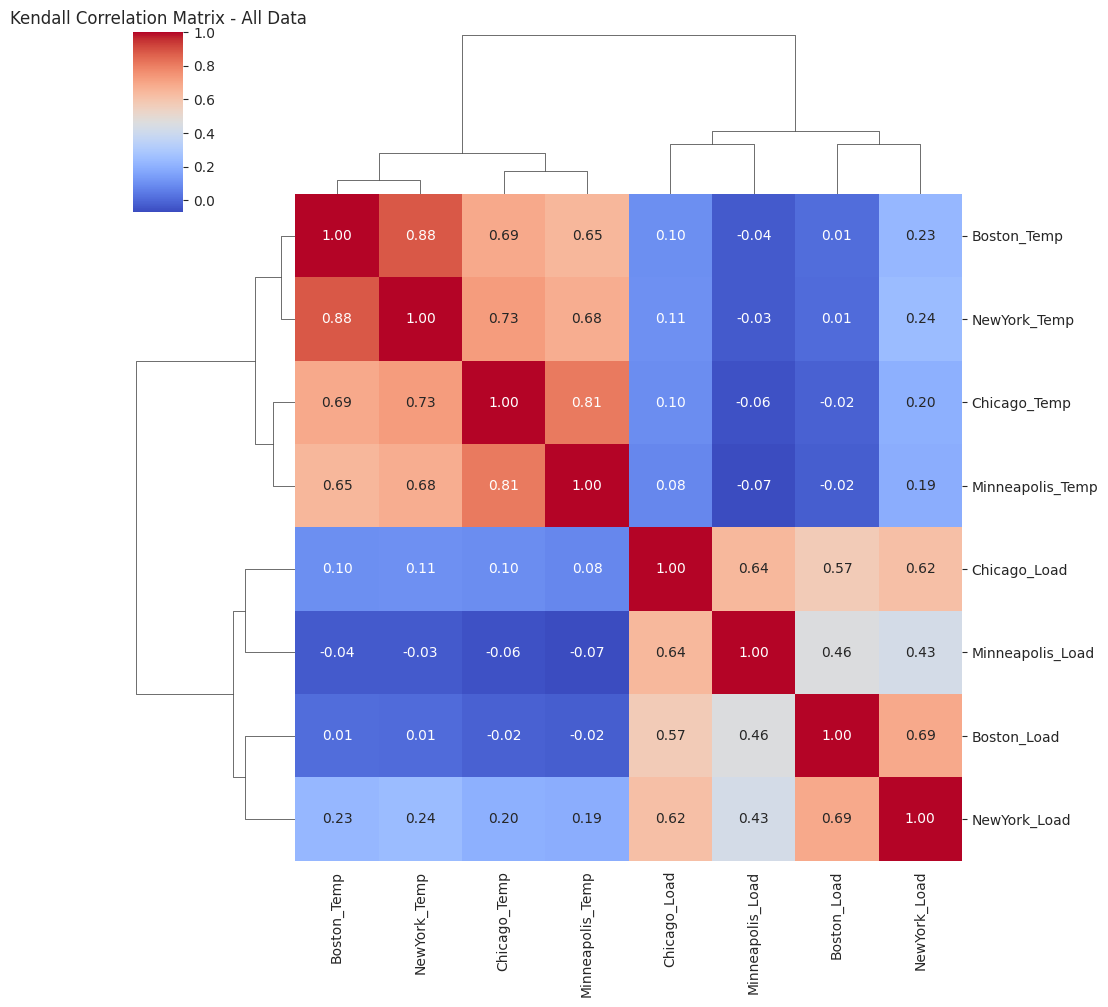

In [8]:
sns.clustermap(all_data_clean.corr(method='kendall'), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Kendall Correlation Matrix - All Data')
plt.show()

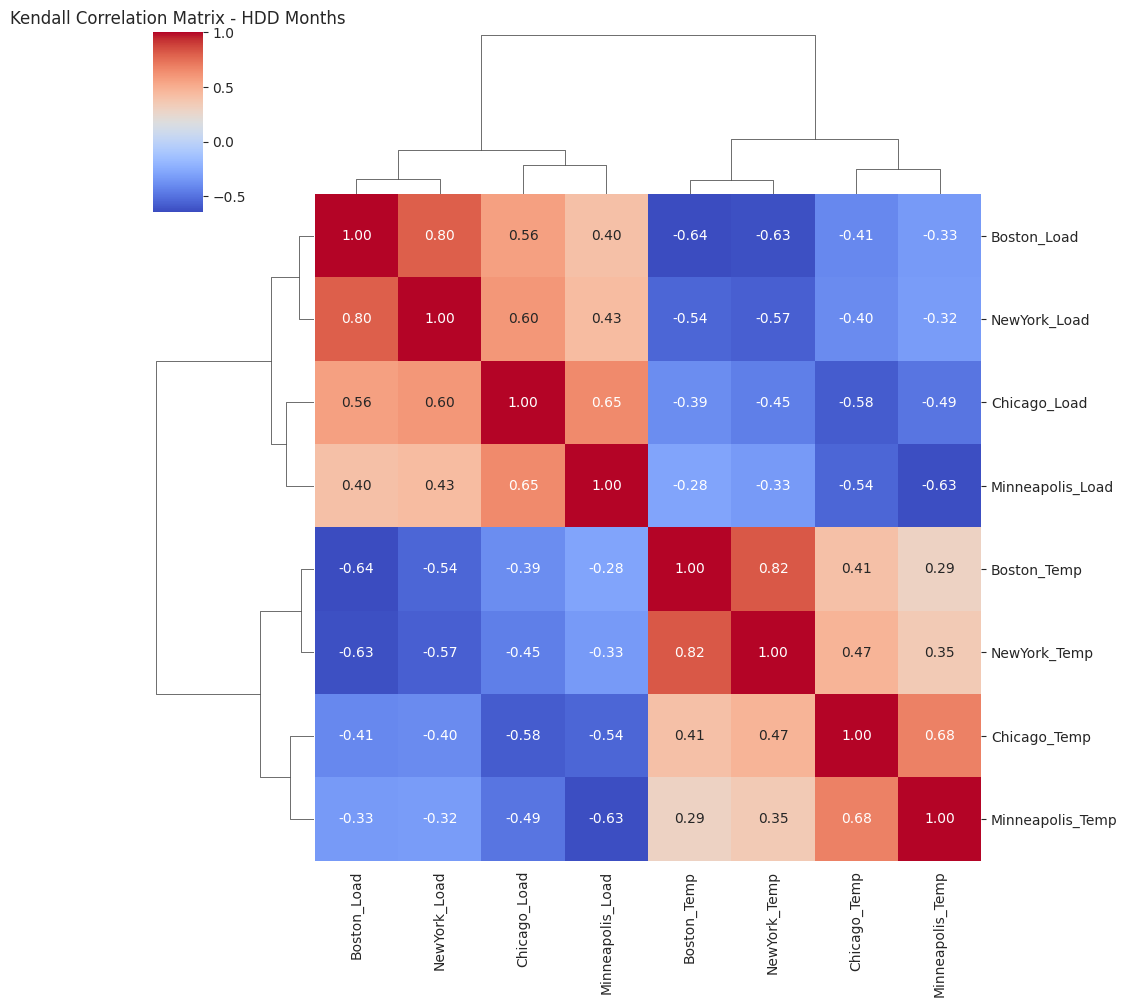

In [9]:
sns.clustermap(all_data_clean_hdd.corr(method='kendall'), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Kendall Correlation Matrix - HDD Months')
plt.show()

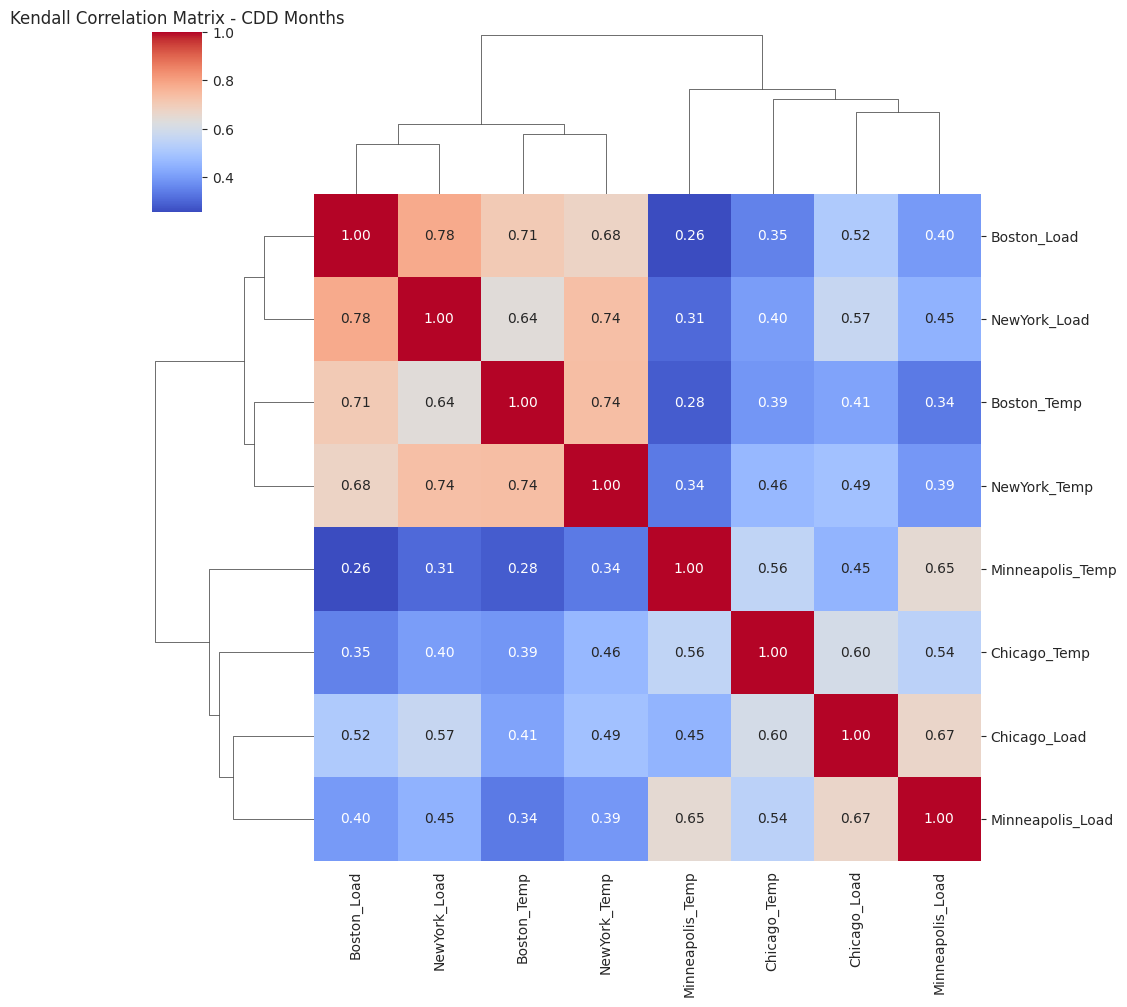

In [10]:
sns.clustermap(all_data_clean_cdd.corr(method='kendall'), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Kendall Correlation Matrix - CDD Months')
plt.show()

## 3.6. Residual Correlation Analysis

Extract residuals from the seasonal models (after removing seasonal patterns) and analyze their correlations.

In [11]:
# Extract residuals from pickle files
# Temperature residuals are in 'df_res' with city names as columns
temp_residuals = temp_data['df_res'].copy()
temp_residuals.columns = [f'{city}_Temp_Resid' for city in temp_residuals.columns]

# Load residuals are also in 'df_res' with city names as columns
load_residuals = load_data['df_res'].copy()
load_residuals.columns = [f'{city}_Load_Resid' for city in load_residuals.columns]

# Combine all residuals
all_residuals = pd.concat([temp_residuals, load_residuals], axis=1)
all_residuals_clean = all_residuals.dropna()

print(f"Residuals data shape: {all_residuals_clean.shape}")
print(f"Date range: {all_residuals_clean.index.min()} to {all_residuals_clean.index.max()}")
print(f"\nColumns: {all_residuals_clean.columns.tolist()}")
print(f"\nTemperature residuals preview:")
print(temp_residuals.head())
print(f"\nLoad residuals preview:")
print(load_residuals.head())

Residuals data shape: (3286, 8)
Date range: 2014-01-01 00:00:00 to 2022-12-30 00:00:00

Columns: ['Boston_Temp_Resid', 'NewYork_Temp_Resid', 'Chicago_Temp_Resid', 'Minneapolis_Temp_Resid', 'NewYork_Load_Resid', 'Boston_Load_Resid', 'Chicago_Load_Resid', 'Minneapolis_Load_Resid']

Temperature residuals preview:
            Boston_Temp_Resid  NewYork_Temp_Resid  Chicago_Temp_Resid  \
date                                                                    
2014-01-01          43.874372           49.593197           41.040282   
2014-01-02         -20.320647          -14.445957           -8.301969   
2014-01-03          -5.052080           -6.517986           -9.991465   
2014-01-04          -2.883154           -2.084672           15.316474   
2014-01-05           8.144326           11.072880          -13.812502   

            Minneapolis_Temp_Resid  
date                                
2014-01-01               26.441416  
2014-01-02               -3.927996  
2014-01-03                8.

In [12]:
# Split residuals by season
all_residuals_hdd = all_residuals_clean[all_residuals_clean.index.month.isin(MONTH_HDD)]
all_residuals_cdd = all_residuals_clean[all_residuals_clean.index.month.isin(MONTH_CDD)]

print(f"Residuals - HDD months: {all_residuals_hdd.shape[0]} days")
print(f"Residuals - CDD months: {all_residuals_cdd.shape[0]} days")
print(f"Residuals - All months: {all_residuals_clean.shape[0]} days")

Residuals - HDD months: 1360 days
Residuals - CDD months: 1377 days
Residuals - All months: 3286 days


<Figure size 1200x1000 with 0 Axes>

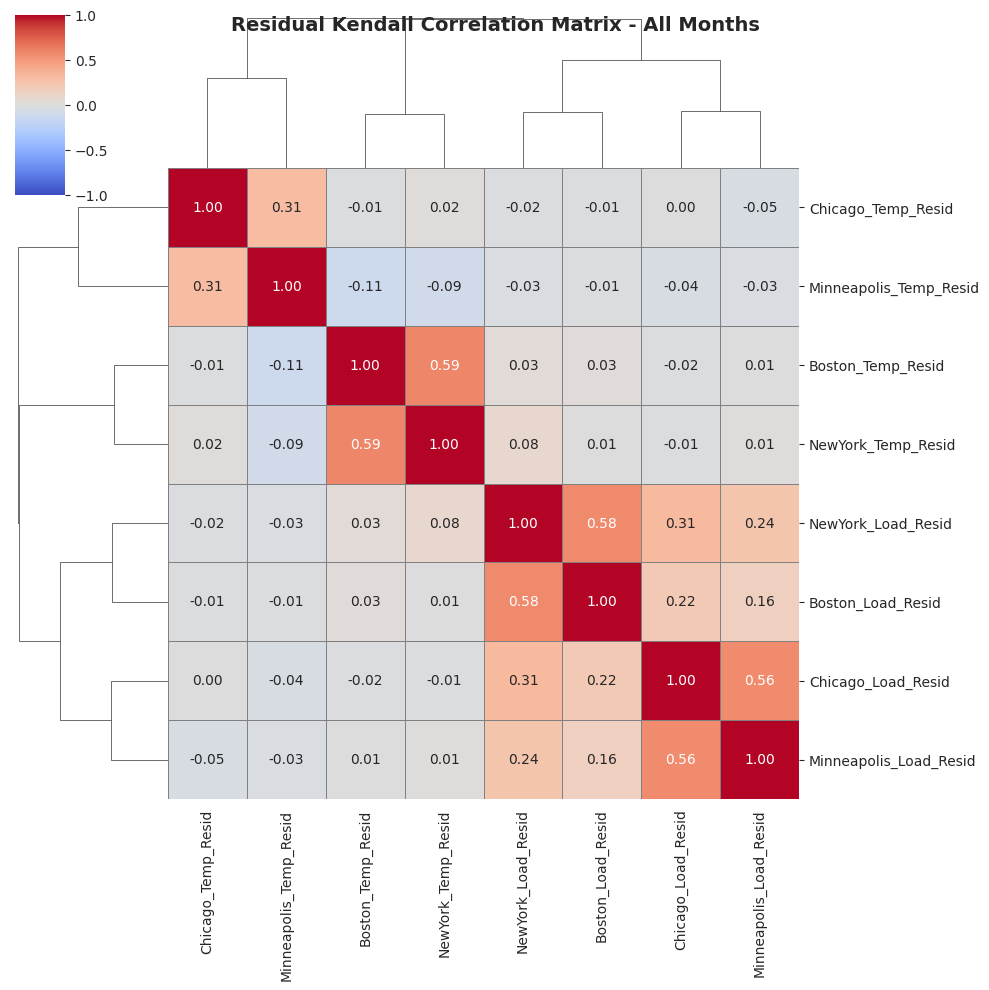

Residual Correlation Statistics (All Months):
       Boston_Temp_Resid  NewYork_Temp_Resid  Chicago_Temp_Resid  \
count           8.000000            8.000000            8.000000   
mean            0.188548            0.201323            0.155846   
std             0.392281            0.385127            0.359886   
min            -0.114176           -0.091197           -0.045071   
25%            -0.014933            0.000845           -0.015279   
50%             0.017302            0.018642           -0.005181   
75%             0.170933            0.210022            0.095631   
max             1.000000            1.000000            1.000000   

       Minneapolis_Temp_Resid  NewYork_Load_Resid  Boston_Load_Resid  \
count                8.000000            8.000000           8.000000   
mean                 0.124711            0.275520           0.245146   
std                  0.377574            0.357023           0.363703   
min                 -0.114176           -0.025845    

In [13]:
# Residual correlations - All months
fig = plt.figure(figsize=(12, 10))
sns.clustermap(all_residuals_clean.corr(method='kendall'), annot=True, fmt=".2f", 
               cmap='coolwarm', center=0, vmin=-1, vmax=1,
               linewidths=0.5, linecolor='gray')
plt.suptitle('Residual Kendall Correlation Matrix - All Months', 
             fontsize=14, fontweight='bold', y=0.98)
plt.savefig('../data/images/residual_correlations_all.png', dpi=300, bbox_inches='tight')
plt.show()

print("Residual Correlation Statistics (All Months):")
print(all_residuals_clean.corr(method='kendall').describe())

<Figure size 1200x1000 with 0 Axes>

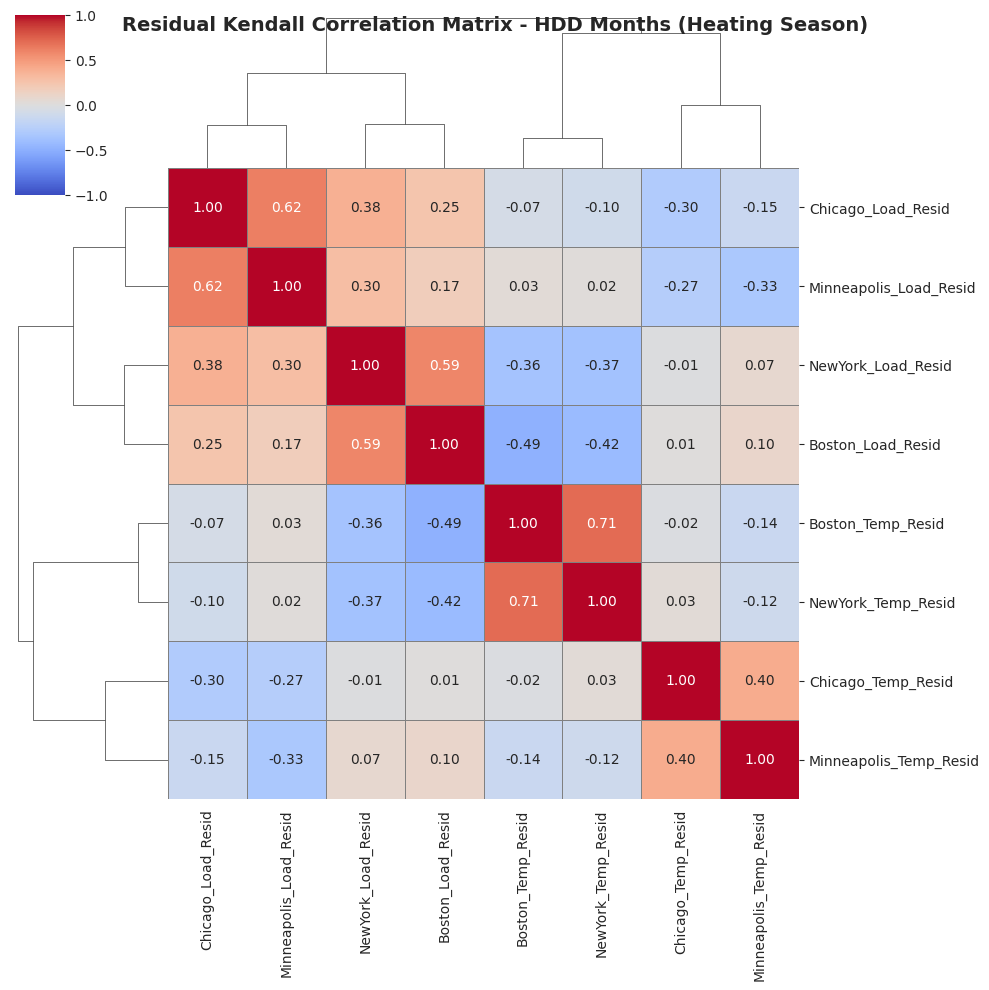

Residual Correlation Statistics (HDD Months):
       Boston_Temp_Resid  NewYork_Temp_Resid  Chicago_Temp_Resid  \
count           8.000000            8.000000            8.000000   
mean            0.083124            0.093646            0.106868   
std             0.512114            0.503211            0.419424   
min            -0.485582           -0.424456           -0.296256   
25%            -0.196535           -0.181115           -0.079745   
50%            -0.043196           -0.037429           -0.000228   
75%             0.202066            0.201175            0.125386   
max             1.000000            1.000000            1.000000   

       Minneapolis_Temp_Resid  NewYork_Load_Resid  Boston_Load_Resid  \
count                8.000000            8.000000           8.000000   
mean                 0.104776            0.198253           0.150871   
std                  0.422638            0.468774           0.490204   
min                 -0.325447           -0.373330    

In [14]:
# Residual correlations - HDD months
fig = plt.figure(figsize=(12, 10))
sns.clustermap(all_residuals_hdd.corr(method='kendall'), annot=True, fmt=".2f", 
               cmap='coolwarm', center=0, vmin=-1, vmax=1,
               linewidths=0.5, linecolor='gray')
plt.suptitle('Residual Kendall Correlation Matrix - HDD Months (Heating Season)', 
             fontsize=14, fontweight='bold', y=0.98)
plt.savefig('../data/images/residual_correlations_hdd.png', dpi=300, bbox_inches='tight')
plt.show()

print("Residual Correlation Statistics (HDD Months):")
print(all_residuals_hdd.corr(method='kendall').describe())

<Figure size 1200x1000 with 0 Axes>

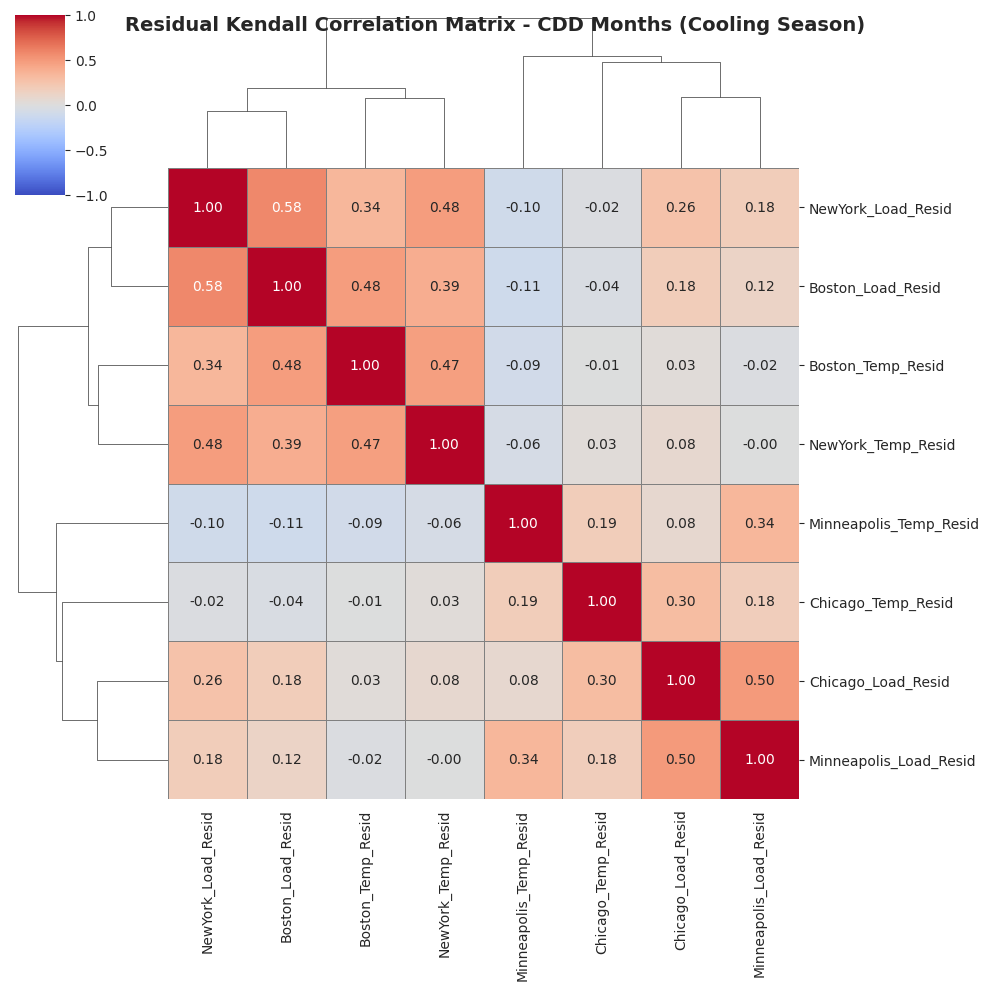

Residual Correlation Statistics (CDD Months):
       Boston_Temp_Resid  NewYork_Temp_Resid  Chicago_Temp_Resid  \
count           8.000000            8.000000            8.000000   
mean            0.274440            0.297979            0.202905   
std             0.373377            0.359700            0.344671   
min            -0.093074           -0.060580           -0.039000   
25%            -0.010769            0.019327           -0.010874   
50%             0.183305            0.233357            0.101443   
75%             0.472873            0.472955            0.215089   
max             1.000000            1.000000            1.000000   

       Minneapolis_Temp_Resid  NewYork_Load_Resid  Boston_Load_Resid  \
count                8.000000            8.000000           8.000000   
mean                 0.155705            0.341580           0.327044   
std                  0.376857            0.351886           0.364667   
min                 -0.107083           -0.095177    

In [15]:
# Residual correlations - CDD months
fig = plt.figure(figsize=(12, 10))
sns.clustermap(all_residuals_cdd.corr(method='kendall'), annot=True, fmt=".2f", 
               cmap='coolwarm', center=0, vmin=-1, vmax=1,
               linewidths=0.5, linecolor='gray')
plt.suptitle('Residual Kendall Correlation Matrix - CDD Months (Cooling Season)', 
             fontsize=14, fontweight='bold', y=0.98)
plt.savefig('../data/images/residual_correlations_cdd.png', dpi=300, bbox_inches='tight')
plt.show()

print("Residual Correlation Statistics (CDD Months):")
print(all_residuals_cdd.corr(method='kendall').describe())

## 4. Ferreira's Tail Dependence Coefficient (TDC) Analysis

The Tail Dependence Coefficient (TDC) measures the probability that extreme values occur simultaneously in two variables. This is particularly important for understanding co-movement during extreme weather/load conditions.

**Reference**: Ferreira, M.S., 2013. Nonparametric estimation of the tail-dependence coefficient

In [16]:
# Import torch for Ferreira TDC calculation
import torch
from wxderivs import unibm

# Define Ferreira's Tail Dependence Coefficient function
def ferreira_tail_dep_coeff(x: torch.Tensor, y: torch.Tensor) -> float:
    """Pairwise tail dependence coefficient (λ) estimator, max of rotation 0, 90, 180, 270
    x and y are both of shape (n, 1) inside (0, 1)
    symmetric for (x,y), (y,1-x), (1-x,1-y), (1-y,x), (y,x), (1-x,y), (1-y,1-x), (x,1-y)
    Ferreira, M.S., 2013. Nonparametric estimation of the tail-dependence coefficient;
    """
    x1 = 1 - x
    y1 = 1 - y
    return (
        3
        - (
            1
            - torch.as_tensor(
                [
                    torch.max(x, y).mean(),
                    torch.max(y, x1).mean(),
                    torch.max(x1, y1).mean(),
                    torch.max(y1, x).mean(),
                ]
            )
            .clamp(0.5, 0.6666666666666666)
            .min()
        ).reciprocal()
    ).item()

print("✓ Ferreira TDC function defined")

✓ Ferreira TDC function defined


In [17]:
# Transform residuals to copula domain (0,1) using empirical CDF
# All months
df_all_cop = all_residuals_clean.apply(lambda vec: unibm.cdf_func_kernel(vec)(vec))

# Calculate TDC matrix for all months
df_tdc_all_res = df_all_cop.corr(
    method=lambda x, y: ferreira_tail_dep_coeff(torch.tensor(x), torch.tensor(y))
)

print("✓ Ferreira TDC calculated for all months")
print(f"TDC Matrix shape: {df_tdc_all_res.shape}")
print(f"\nTDC Statistics (All Months):")
print(df_tdc_all_res.describe())

✓ Ferreira TDC calculated for all months
TDC Matrix shape: (8, 8)

TDC Statistics (All Months):
       Boston_Temp_Resid  NewYork_Temp_Resid  Chicago_Temp_Resid  \
count           8.000000            8.000000            8.000000   
mean            0.263982            0.265691            0.207387   
std             0.367718            0.366552            0.343317   
min             0.018296            0.024988            0.013544   
25%             0.039536            0.044102            0.035665   
50%             0.084247            0.098640            0.054160   
75%             0.296425            0.278957            0.158537   
max             1.000000            1.000000            1.000000   

       Minneapolis_Temp_Resid  NewYork_Load_Resid  Boston_Load_Resid  \
count                8.000000            8.000000           8.000000   
mean                 0.237403            0.339536           0.300478   
std                  0.330177            0.349503           0.358613   
min

<Figure size 1400x1200 with 0 Axes>

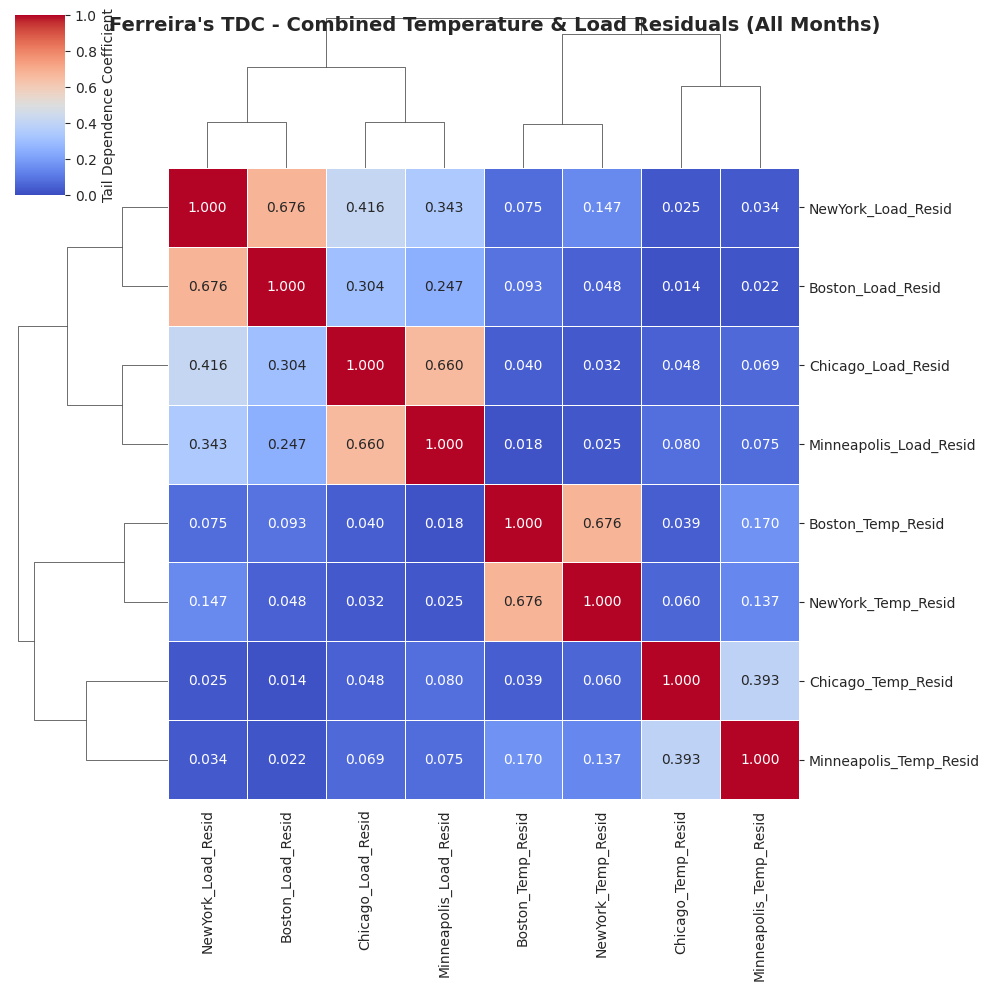

✓ TDC heatmap saved: combined_ferreira_tdc_all.png


In [ ]:
# Visualize TDC matrix for all months
fig = plt.figure(figsize=(14, 12))
g = sns.clustermap(
    df_tdc_all_res,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    linewidths=0.5,
    vmin=0,
    vmax=1,
    cbar_kws={'label': 'Tail Dependence Coefficient'}
)
plt.suptitle("Ferreira's TDC - Combined Temperature & Load Residuals (All Months)", 
             fontsize=14, fontweight='bold', y=0.98)
plt.savefig('../data/images/combined_ferreira_tdc_all.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1400x1200 with 0 Axes>

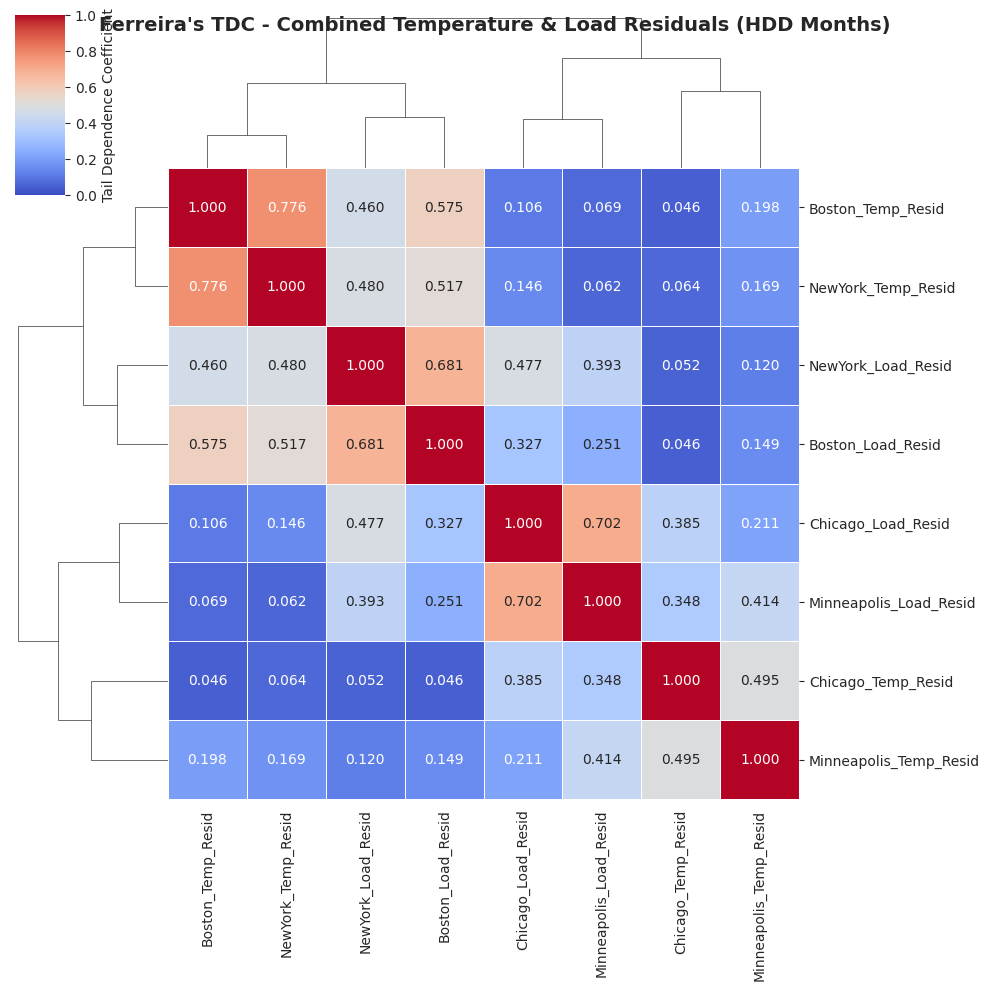

✓ TDC heatmap saved: combined_ferreira_tdc_hdd.png

TDC Statistics (HDD Months):
       Boston_Temp_Resid  NewYork_Temp_Resid  Chicago_Temp_Resid  \
count           8.000000            8.000000            8.000000   
mean            0.403735            0.401750            0.304441   
std             0.358077            0.351717            0.334588   
min             0.046002            0.061576            0.045923   
25%             0.096672            0.125843            0.050151   
50%             0.329046            0.324674            0.206156   
75%             0.625204            0.581455            0.412529   
max             1.000000            1.000000            1.000000   

       Minneapolis_Temp_Resid  NewYork_Load_Resid  Boston_Load_Resid  \
count                8.000000            8.000000           8.000000   
mean                 0.344479            0.457771           0.443193   
std                  0.296616            0.299589           0.312599   
min               

In [19]:
# Calculate TDC for HDD months (heating season)
df_hdd_cop = all_residuals_hdd.apply(lambda vec: unibm.cdf_func_kernel(vec)(vec))
df_tdc_hdd_res = df_hdd_cop.corr(
    method=lambda x, y: ferreira_tail_dep_coeff(torch.tensor(x), torch.tensor(y))
)

# Visualize TDC matrix for HDD months
fig = plt.figure(figsize=(14, 12))
g = sns.clustermap(
    df_tdc_hdd_res,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    linewidths=0.5,
    vmin=0,
    vmax=1,
    cbar_kws={'label': 'Tail Dependence Coefficient'}
)
plt.suptitle("Ferreira's TDC - Combined Temperature & Load Residuals (HDD Months)", 
             fontsize=14, fontweight='bold', y=0.98)
plt.savefig('../data/images/combined_ferreira_tdc_hdd.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ TDC heatmap saved: combined_ferreira_tdc_hdd.png")
print(f"\nTDC Statistics (HDD Months):")
print(df_tdc_hdd_res.describe())

<Figure size 1400x1200 with 0 Axes>

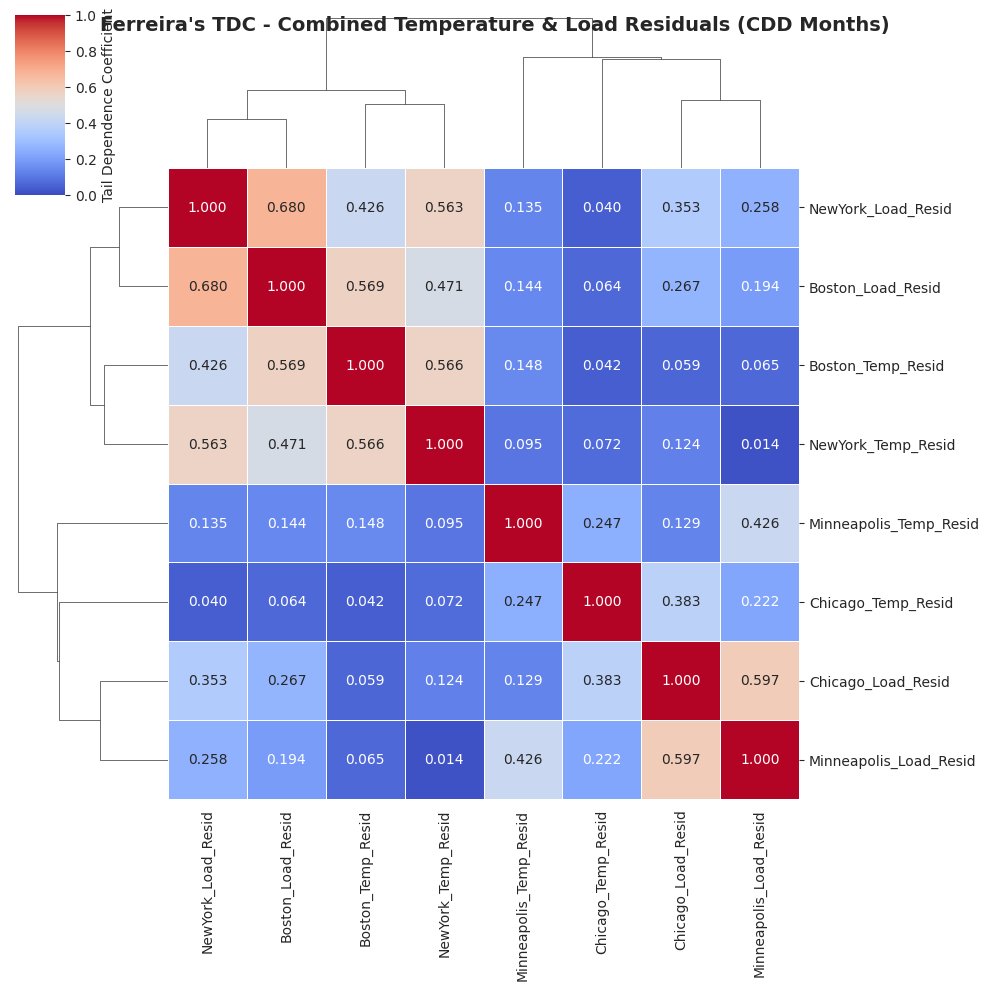

✓ TDC heatmap saved: combined_ferreira_tdc_cdd.png

TDC Statistics (CDD Months):
       Boston_Temp_Resid  NewYork_Temp_Resid  Chicago_Temp_Resid  \
count           8.000000            8.000000            8.000000   
mean            0.359315            0.363176            0.258819   
std             0.343013            0.345118            0.323810   
min             0.042111            0.013998            0.040275   
25%             0.063313            0.089531            0.058697   
50%             0.287086            0.297787            0.146594   
75%             0.566618            0.563555            0.281432   
max             1.000000            1.000000            1.000000   

       Minneapolis_Temp_Resid  NewYork_Load_Resid  Boston_Load_Resid  \
count                8.000000            8.000000           8.000000   
mean                 0.290705            0.431812           0.423659   
std                  0.305582            0.311494           0.317452   
min               

In [ ]:
# Calculate TDC for CDD months (cooling season)
df_cdd_cop = all_residuals_cdd.apply(lambda vec: unibm.cdf_func_kernel(vec)(vec))
df_tdc_cdd_res = df_cdd_cop.corr(
    method=lambda x, y: ferreira_tail_dep_coeff(torch.tensor(x), torch.tensor(y))
)

# Visualize TDC matrix for CDD months
fig = plt.figure(figsize=(14, 12))
g = sns.clustermap(
    df_tdc_cdd_res,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    linewidths=0.5,
    vmin=0,
    vmax=1,
    cbar_kws={'label': 'Tail Dependence Coefficient'}
)
plt.suptitle("Ferreira's TDC - Combined Temperature & Load Residuals (CDD Months)", 
             fontsize=14, fontweight='bold', y=0.98)
plt.savefig('../data/images/combined_ferreira_tdc_cdd.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.1. TDC Interpretation and Key Findings

**Tail Dependence Coefficient (TDC) Interpretation:**
- **TDC = 0**: No tail dependence (variables are independent in the tails)
- **TDC = 1**: Perfect tail dependence (extreme values always occur together)
- **0 < TDC < 1**: Partial tail dependence (higher values indicate stronger co-movement during extremes)

**Key Insights:**
1. **Temperature-Temperature TDC**: Shows spatial correlation of extreme temperature events
2. **Load-Load TDC**: Indicates co-movement of extreme demand across cities
3. **Temperature-Load TDC**: Reveals how extreme temperature events drive extreme demand events

## 5. Summary and Export Results

Save key results for inclusion in PROJECT_REPORT.md

In [ ]:
# Export TDC results to CSV for reporting
df_tdc_all_res.to_csv('../data/processed/combined_tdc_all_months.csv')
df_tdc_hdd_res.to_csv('../data/processed/combined_tdc_hdd_months.csv')
df_tdc_cdd_res.to_csv('../data/processed/combined_tdc_cdd_months.csv')

✓ TDC results exported to CSV files

Files saved:
  - ../data/processed/combined_tdc_all_months.csv
  - ../data/processed/combined_tdc_hdd_months.csv
  - ../data/processed/combined_tdc_cdd_months.csv

✓ Analysis complete! See PROJECT_REPORT.md Section 9.5 for detailed findings.
